In [1]:
import pandas as pd
import string
import math
import re 
from tqdm.auto import tqdm
from scipy.stats import kendalltau
from sklearn.model_selection import train_test_split

def normalize_answer(s):
    """Lower text and remove punctuation and extra whitespace."""


    def white_space_fix(text):
        return ' '.join(text.split())

    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_punc(lower(s)))

import evaluate
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F
from sklearn.metrics import f1_score, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TextClassificationPipeline
from scipy.stats import gmean
import numpy

def calculate_BERTSCORE(predictions, references):

  bleurt = evaluate.load("bertscore")
  return numpy.mean(bleurt.compute(predictions=predictions, references=references, lang="pt")["f1"])

def bert_fscore(predictions, references):
  bleurt = evaluate.load("bertscore")
  return bleurt.compute(predictions=predictions, references=references, lang="pt")["f1"]

#Mean Pooling - Take attention mask into account for correct averaging
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] #First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)



def compute_labse(candidates, references):

    distances = []
    tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/LaBSE')
    model = AutoModel.from_pretrained('sentence-transformers/LaBSE')

    # Tokenize sentences
    tokens_candidates = tokenizer(candidates, padding=True, truncation=True, return_tensors='pt')
    tokens_references = tokenizer(references, padding=True, truncation=True, return_tensors='pt')
    # Compute token embeddings
    with torch.no_grad():
        model_candidates = model(**tokens_candidates)
        model_references = model(**tokens_references)

    # Perform pooling
    embeddings_candidates = F.normalize(mean_pooling(model_candidates, tokens_candidates['attention_mask']), p=2, dim=1)
    embeddings_references = F.normalize(mean_pooling(model_references, tokens_references['attention_mask']), p=2, dim=1)

    for ele1, ele2 in zip(embeddings_candidates, embeddings_references):
        ele1 = ele1.unsqueeze(0)
        ele2 = ele2.unsqueeze(0)
        distances.append(F.cosine_similarity(ele1, ele2))
    return numpy.mean(distances)

def get_labses(candidates, references):

    distances = []
    tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/LaBSE')
    model = AutoModel.from_pretrained('sentence-transformers/LaBSE')

    # Tokenize sentences
    tokens_candidates = tokenizer(candidates, padding=True, truncation=True, return_tensors='pt')
    tokens_references = tokenizer(references, padding=True, truncation=True, return_tensors='pt')
    # Compute token embeddings
    with torch.no_grad():
        model_candidates = model(**tokens_candidates)
        model_references = model(**tokens_references)

    # Perform pooling
    embeddings_candidates = F.normalize(mean_pooling(model_candidates, tokens_candidates['attention_mask']), p=2, dim=1)
    embeddings_references = F.normalize(mean_pooling(model_references, tokens_references['attention_mask']), p=2, dim=1)

    for ele1, ele2 in zip(embeddings_candidates, embeddings_references):
        ele1 = ele1.unsqueeze(0)
        ele2 = ele2.unsqueeze(0)
        distances.append(F.cosine_similarity(ele1, ele2))
    return distances



def compute_acc(candidates, true_labels):

    labels = {'r2_lu_876': 0, 'r2_cl_2165': 1, 'r2_gl_1071': 2, 'r2_bo_344': 3, 'r2_bo_208': 4, 'r2_lu_94': 5}
    model     = AutoModelForSequenceClassification.from_pretrained("../dataset/data/ustance/classification/results/checkpoint-520/")
    tokenizer = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")
    tokenizer.padding_side = "right"  # Fix weird overflow issue with fp16 training
    model = TextClassificationPipeline(model=model, tokenizer=tokenizer, top_k=1)
    preds = []
    for pred in model(candidates, truncation=True, padding=True, max_length=512):
        preds.append(int(pred[0]["label"].split("LABEL_")[1]))
    results = f1_score(preds, [labels[x] for x in true_labels], average="weighted")

    return results


seed = 14

df_original = pd.read_csv("./data_set.csv", sep="\t")
df_llama    = pd.read_csv("./testes/preds_llama.txt", sep="\t", header=None).rename(columns={0: "llama_outs"}, inplace=False)
df_qwen     = pd.read_csv("./testes/preds_qwen.txt", sep="\t", header=None).rename(columns={0: "qwen_outs"}, inplace=False)


train, test = train_test_split(df_original, test_size=0.2, random_state=seed)

test.reset_index(inplace=True)
test.drop(columns=["index"], inplace=True)

In [2]:
df_final = pd.concat([df_llama, df_qwen, test], axis=1)

In [3]:
df_final

,llama_outs,qwen_outs,reescrito,estilo_academico,user_id,estilo_autoral
0,"Desculpa, mas fala como se ele foi capaz de ex...","O povo do PT, parece não sabe falar com clareza","<think>\nOkay, let's tackle this. The user wan...","Perdoe-me, mas a afirmação de que os membros d...",r2_bo_208,Oi? Petista não sabe nem falar. Eu hein
1,Com respeito e admiração eu te cumpro ao pasto...,Parabéns ao pastor verdadeiro homem de DEUS!,"<think>\nOkay, let's tackle this text rewritin...","Com profundo respeito e reconhecimento, dedico...",r2_lu_876,"Em homenagem ao meu Pastor Homem de D""us um t..."
2,Felipe jornalista não é um referencial,Felipe não é referência de jornalista,"<think>\nOkay, let's tackle this rephrasing ta...",O profissional de jornalismo Felipe não é cons...,r2_bo_208,Não tenho como referência o jornalista Felipe.
3,"Foi um abuso da nossa jornalista, ela forçou H...",Me fizeram um lero-lero. Qualquer um que for p...,"<think>\nOkay, let's tackle this rewriting tas...",O evento demonstrou uma situação problemática....,r2_cl_2165,O TIRO SAIU PELA CULATRA!!!... QUEM É BANDIDO...
4,esse hominídeio é desagradável,Esse cara é um nojento,"<think>\nOkay, let's tackle this reescrita tex...",Este indivíduo é claramente desagradável.,r2_gl_1071,Esse freixo é um FDP!
...,...,...,...,...,...,...
100,Deputada federal Janaína Paschoal questiona CP...,Deputada questiona investigação da CPI das Not...,"<think>\nOkay, I need to rephrase the given te...",A deputada federal Janaína Paschoal manifestou...,r2_cl_2165,Janaína Paschoal questiona se CPI das ‘Fake N...
101,Rindo barato sai o povo,Rindo muito ela se sai,"<think>\nOkay, let's tackle this. The user wan...","Rindo de forma exagerada, manifeste a saída da...",r2_bo_344,AAHAHAHHAHHAHH VAZAAAAA
102,"Ministro Weintraub, da Comissão Parlamentar Mi...",AO VIVO: Weintraub acusa senadores da esquerda...,"<think>\nOkay, let's tackle this. The user wan...","Durante transmissão ao vivo, o ministro Abraha...",r2_cl_2165,AO VIVO: MINISTRO ABRAHAM WEINTRAUB CONFRONTA...
103,Síria: Forças militares ocidentais se moviment...,Síria - as forças ocidentais ocupam posições e...,"<think>\nOkay, let's tackle this text rewritin...",Síria: Forças militares ocidentais encontram-s...,r2_lu_876,Síria: Forças militares do Ocidente já ocupam...


In [4]:
df_final["qwen_clean"] = df_final["qwen_outs"].apply(lambda x: normalize_answer(x))
df_final["original_clean"] = df_final["estilo_autoral"].apply(lambda x: normalize_answer(x))

df_final["fscore"] = bert_fscore(df_final["qwen_clean"].tolist(), df_final["original_clean"].tolist())

df_final["labse"] = get_labses = get_labses(df_final["qwen_clean"].tolist(), df_final["original_clean"].tolist())



In [5]:
df_final

,llama_outs,qwen_outs,reescrito,estilo_academico,user_id,estilo_autoral,qwen_clean,original_clean,fscore,labse
0,"Desculpa, mas fala como se ele foi capaz de ex...","O povo do PT, parece não sabe falar com clareza","<think>\nOkay, let's tackle this. The user wan...","Perdoe-me, mas a afirmação de que os membros d...",r2_bo_208,Oi? Petista não sabe nem falar. Eu hein,o povo do pt parece não sabe falar com clareza,oi petista não sabe nem falar eu hein,0.731733,[tensor(0.6921)]
1,Com respeito e admiração eu te cumpro ao pasto...,Parabéns ao pastor verdadeiro homem de DEUS!,"<think>\nOkay, let's tackle this text rewritin...","Com profundo respeito e reconhecimento, dedico...",r2_lu_876,"Em homenagem ao meu Pastor Homem de D""us um t...",parabéns ao pastor verdadeiro homem de deus,em homenagem ao meu pastor homem de dus um ter...,0.709400,[tensor(0.7419)]
2,Felipe jornalista não é um referencial,Felipe não é referência de jornalista,"<think>\nOkay, let's tackle this rephrasing ta...",O profissional de jornalismo Felipe não é cons...,r2_bo_208,Não tenho como referência o jornalista Felipe.,felipe não é referência de jornalista,não tenho como referência o jornalista felipe,0.779384,[tensor(0.9015)]
3,"Foi um abuso da nossa jornalista, ela forçou H...",Me fizeram um lero-lero. Qualquer um que for p...,"<think>\nOkay, let's tackle this rewriting tas...",O evento demonstrou uma situação problemática....,r2_cl_2165,O TIRO SAIU PELA CULATRA!!!... QUEM É BANDIDO...,me fizeram um lerolero qualquer um que for pre...,o tiro saiu pela culatra quem é bandido bandid...,0.733345,[tensor(0.8166)]
4,esse hominídeio é desagradável,Esse cara é um nojento,"<think>\nOkay, let's tackle this reescrita tex...",Este indivíduo é claramente desagradável.,r2_gl_1071,Esse freixo é um FDP!,esse cara é um nojento,esse freixo é um fdp,0.758340,[tensor(0.6950)]
...,...,...,...,...,...,...,...,...,...,...
100,Deputada federal Janaína Paschoal questiona CP...,Deputada questiona investigação da CPI das Not...,"<think>\nOkay, I need to rephrase the given te...",A deputada federal Janaína Paschoal manifestou...,r2_cl_2165,Janaína Paschoal questiona se CPI das ‘Fake N...,deputada questiona investigação da cpi das not...,janaína paschoal questiona se cpi das ‘fake ne...,0.677280,[tensor(0.8383)]
101,Rindo barato sai o povo,Rindo muito ela se sai,"<think>\nOkay, let's tackle this. The user wan...","Rindo de forma exagerada, manifeste a saída da...",r2_bo_344,AAHAHAHHAHHAHH VAZAAAAA,rindo muito ela se sai,aahahahhahhahh vazaaaaa,0.610253,[tensor(0.4197)]
102,"Ministro Weintraub, da Comissão Parlamentar Mi...",AO VIVO: Weintraub acusa senadores da esquerda...,"<think>\nOkay, let's tackle this. The user wan...","Durante transmissão ao vivo, o ministro Abraha...",r2_cl_2165,AO VIVO: MINISTRO ABRAHAM WEINTRAUB CONFRONTA...,ao vivo weintraub acusa senadores da esquerda ...,ao vivo ministro abraham weintraub confronta s...,0.766334,[tensor(0.8707)]
103,Síria: Forças militares ocidentais se moviment...,Síria - as forças ocidentais ocupam posições e...,"<think>\nOkay, let's tackle this text rewritin...",Síria: Forças militares ocidentais encontram-s...,r2_lu_876,Síria: Forças militares do Ocidente já ocupam...,síria as forças ocidentais ocupam posições em ...,síria forças militares do ocidente já ocupam p...,0.890557,[tensor(0.9165)]


In [6]:
import nltk

def tokenize_text(text):
    """
    Tokenizes the input text into sentences and words.
    """
    tokenized_sentences = [nltk.word_tokenize(sentence, language='portuguese') for sentence in text]
    return len(tokenized_sentences)

In [7]:
import numpy as np
df_final['mean'] = df_final.apply(lambda x: np.mean([x['fscore'], x['labse'].tolist()[0]]), axis=1)

In [8]:
df_final['tokens_original'] = df_final["original_clean"].apply(lambda x: tokenize_text(x))
df_final['tokens_qwen'] = df_final["qwen_clean"].apply(lambda x: tokenize_text(x))

In [9]:
df_final.groupby("user_id").agg({
    "fscore": "mean",
    "labse": "mean",
    "mean": "mean"}).reset_index().sort_values("mean", ascending=False)


,user_id,fscore,labse,mean
4,r2_lu_876,0.786218,0.835973,0.811096
3,r2_gl_1071,0.764577,0.816644,0.790610
2,r2_cl_2165,0.732057,0.847984,0.790020
0,r2_bo_208,0.774002,0.773785,0.773894
5,r2_lu_94,0.733171,0.813179,0.773175
1,r2_bo_344,0.737857,0.735739,0.736798


In [10]:
df_final.groupby("user_id").agg({
    "fscore": "mean",
    "labse": "mean",
    "mean": "mean",
    "tokens_original": "mean",
    'tokens_qwen': "mean"}).reset_index().sort_values("mean", ascending=False)

,user_id,fscore,labse,mean,tokens_original,tokens_qwen
4,r2_lu_876,0.786218,0.835973,0.811096,63.107143,62.214286
3,r2_gl_1071,0.764577,0.816644,0.790610,103.416667,89.708333
2,r2_cl_2165,0.732057,0.847984,0.790020,148.153846,153.461538
0,r2_bo_208,0.774002,0.773785,0.773894,60.187500,56.812500
5,r2_lu_94,0.733171,0.813179,0.773175,271.666667,201.666667
1,r2_bo_344,0.737857,0.735739,0.736798,48.800000,57.933333


In [27]:
# Pré-processando a coluna 'labse' que está com valores em formato de string 'tensor([value])'
df_final['labse_clean'] = df_final['labse'].astype(float)

# Verificando se a limpeza foi bem-sucedida
df_final[['labse', 'labse_clean']].head()

,labse,labse_clean
0,[tensor(0.6921)],0.692091
1,[tensor(0.7419)],0.741879
2,[tensor(0.9015)],0.901505
3,[tensor(0.8166)],0.816645
4,[tensor(0.6950)],0.694973


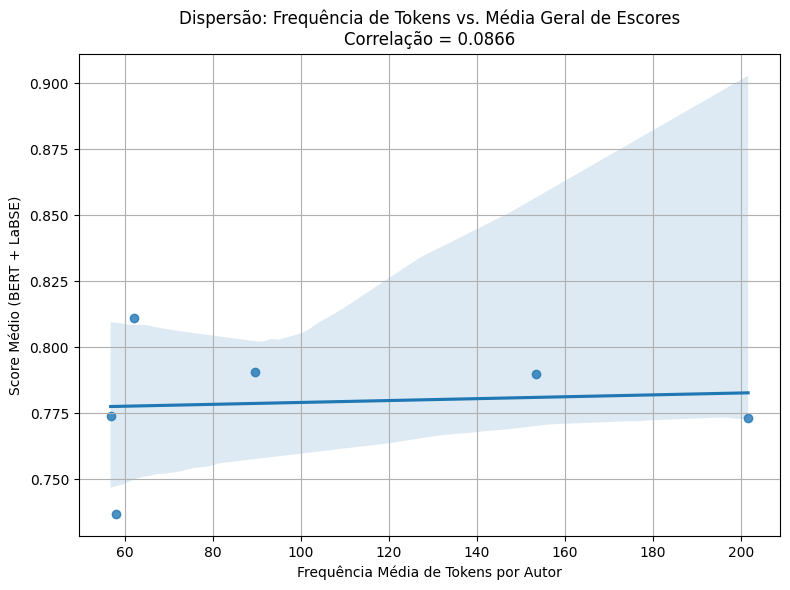

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Cálculo da média por usuário
df_user_scores = df_final.groupby('user_id')[['fscore', 'labse_clean']].mean().reset_index()
df_user_scores['media_geral'] = df_user_scores[['fscore', 'labse_clean']].mean(axis=1)

# Cálculo da frequência média de tokens por autor
df_user_tokens = df_final.groupby('user_id')['tokens_qwen'].mean().reset_index()
df_user_tokens.rename(columns={'tokens_qwen': 'freq_tokens'}, inplace=True)

# Mesclando os dois dataframes
df_analysis = pd.merge(df_user_scores, df_user_tokens, on='user_id')

# Calculando correlação entre frequência de tokens e desempenho médio
correlation = df_analysis['freq_tokens'].corr(df_analysis['media_geral'])

# Gráfico de dispersão
plt.figure(figsize=(8, 6))
sns.regplot(data=df_analysis, x='freq_tokens', y='media_geral', scatter=True)
plt.title(f'Dispersão: Frequência de Tokens vs. Média Geral de Escores\nCorrelação = {correlation:.4f}')
plt.xlabel('Frequência Média de Tokens por Autor')
plt.ylabel('Score Médio (BERT + LaBSE)')
plt.grid(True)
plt.tight_layout()
plt.savefig("./dispersao_tokens_scores.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

In [10]:
def extrair_amostras_por_quartil(df, coluna_interesse):
    """
    Extrai 2 exemplos de cada quartil da coluna de interesse de um DataFrame.

    Parâmetros:
        df (pd.DataFrame): DataFrame de entrada.
        coluna_interesse (str): Nome da coluna com valores entre 0 e 1.

    Retorna:
        pd.DataFrame: Subconjunto com 8 amostras (2 por quartil).
    """
    # Garante que não há valores nulos
    df = df.dropna(subset=[coluna_interesse])

    # Calcula os quartis
    q1 = df[coluna_interesse].quantile(0.25)
    q2 = df[coluna_interesse].quantile(0.50)
    q3 = df[coluna_interesse].quantile(0.75)

    # Define os intervalos de quartis
    condicoes = [
        df[coluna_interesse] <= q1,
        (df[coluna_interesse] > q1) & (df[coluna_interesse] <= q2),
        (df[coluna_interesse] > q2) & (df[coluna_interesse] <= q3),
        df[coluna_interesse] > q3
    ]

    amostras = []
    for cond in condicoes:
        amostras_quartil = df[cond].sample(n=2, random_state=42)
        amostras.append(amostras_quartil)

    resultado = pd.concat(amostras)
    return resultado.reset_index(drop=True)

In [17]:
df_analise = extrair_amostras_por_quartil(df_final, "fscore").sort_values("fscore", ascending=False)

In [21]:
df_analise

,llama_outs,qwen_outs,reescrito,estilo_academico,user_id,estilo_autoral,qwen_clean,original_clean,fscore
7,Exército israelense lancia Tammuz na fronteira...,Exército de Israel atira míssil Tammuz na fron...,"<think>\nOkay, I need to rephrase the original...",O Exército israelense efetuou o lançamento de ...,r2_lu_876,O Exército israelense disparou um míssil Tamm...,exército de israel atira míssil tammuz na fron...,o exército israelense disparou um míssil tammu...,0.862422
6,Mandem a revolução p/ cair novamente,Que um novo Pernambuco Revolução aconteça.,"<think>\nOkay, let's tackle this. The user wan...",Expressar o desejo de que outra Revolução Pern...,r2_bo_344,Rezando pra outra Revolução Pernambucana acon...,que um novo pernambuco revolução aconteça,rezando pra outra revolução pernambucana acont...,0.825307
4,"FHC, homem habilíssimo, é um dos responsáveis ...","FHC o mágico, foi o arquiteto do Foro de São P...","<think>\nOkay, let's see. The user wants me to...","Fernando Henrique Cardoso, figura política hab...",r2_gl_1071,"FHC, raposa política, e um dos culpados pelo ...",fhc o mágico foi o arquiteto do foro de são pa...,fhc raposa política e um dos culpados pelo for...,0.793167
5,Ficou em uma trama dramática xD,"A finalização dessa história vai ser um drama,...","<think>\nOkay, let's tackle this. The user wan...",O desfecho inesperado dessa narrativa será rei...,r2_bo_344,O PLOT TWITS DESSA HISTÓRIA VAI VIRAR NOVELA ...,a finalização dessa história vai ser um drama ...,o plot twits dessa história vai virar novela a...,0.792278
2,Pega-se a atenção ao Vale dos Esquecidos no es...,"ATENÇÃO AO VALE DOS ESQUECIDOS- MT, LOCAL QUE ...","<think>\nOkay, the user wants me to rephrase t...",Instamos que seja dada atenção ao Vale dos Esq...,r2_gl_1071,"Peço que também olhem, para nós do Vale dos E...",atenção ao vale dos esquecidos mt local que é ...,peço que também olhem para nós do vale dos esq...,0.726745
3,"Acha melhor residência na Venezuela, sr. Wagne...",Wagner Moura pense em morar na Venezuela! Jove...,"<think>\nOkay, let's tackle this rewrites task...",Recomenda-se que o Sr. Wagner Moura avalie a h...,r2_gl_1071,"Ôh, Wagner Moura! Porque não vai morar na Ven...",wagner moura pense em morar na venezuela jovem...,ôh wagner moura porque não vai morar na venezu...,0.721317
1,Esquema dos 0 mil médicos cubanos promovido pe...,O Mito de contratar milhares de médicos cubano...,"<think>\nOkay, the user wants me to rewrite a ...",O caso da contratação de milhares de médicos c...,r2_lu_94,@ Rachadinha genial mesmo foi a dos 0 mil méd...,o mito de contratar milhares de médicos cubano...,rachadinha genial mesmo foi a dos 0 mil médico...,0.715065
0,"Olá, amigo! Vem aqui, nos enriquecer!","Seja bem-vindo, guest! Escrever aqui tornará e...","<think>\nOkay, I need to rephrase the given te...","Seja bem-vindo, visitante! Sua participação co...",r2_lu_876,Seja bem vindo amigo vai enriquecer a pagina ...,seja bemvindo guest escrever aqui tornará esta...,seja bem vindo amigo vai enriquecer a pagina w...,0.605874


In [22]:
for line in df_analise.itertuples():
    print(f"Fscore: {line.fscore}")
    print(f"Estilo academico: {line.estilo_academico}")
    print(f"Qwen: {line.qwen_outs}")
    print(f"Original: {line.estilo_autoral}")
    
    print("-" * 50)

Fscore: 0.8624219298362732
Estilo academico: O Exército israelense efetuou o lançamento de um míssil Tammuz em direção à fronteira com a Síria, como resposta ao fogo de morteiros realizado anteriormente.
Qwen: Exército de Israel atira míssil Tammuz na fronteira com Síria depois de ser alvo de fogo de morteiros
Original:  O Exército israelense disparou um míssil Tammuz através da fronteira com a Síria, em resposta ao fogo de morteiro... 
--------------------------------------------------
Fscore: 0.8253071904182434
Estilo academico: Expressar o desejo de que outra Revolução Pernambucana, evento histórico significativo, possa ocorrer novamente.
Qwen: Que um novo Pernambuco Revolução aconteça.
Original:  Rezando pra outra Revolução Pernambucana acontecer! 
--------------------------------------------------
Fscore: 0.7931668758392334
Estilo academico: Fernando Henrique Cardoso, figura política habilidosa, é considerado um dos responsáveis pelo Foro de São Paulo, bem como pela situação de cr

In [3]:
labels = {'r2_lu_876': 0, 'r2_cl_2165': 1, 'r2_gl_1071': 2, 'r2_bo_344': 3, 'r2_bo_208': 4, 'r2_lu_94': 5}

for x in df_final["user_id"].unique():
    print(labels[x], x)

4 r2_bo_208
0 r2_lu_876
1 r2_cl_2165
2 r2_gl_1071
3 r2_bo_344
5 r2_lu_94


In [4]:
df_final["qwen_clean"] = df_final["qwen_outs"].apply(lambda x: normalize_answer(x))
df_final["original_clean"] = df_final["estilo_autoral"].apply(lambda x: normalize_answer(x))



print("Calculating BERTSCORE, LaBSE and ACC for Qwen...")

fscore = calculate_BERTSCORE(df_final["qwen_clean"].tolist(), df_final["original_clean"].tolist())
labse  = compute_labse(df_final["qwen_clean"].tolist(), df_final["original_clean"].tolist())
acc    = compute_acc(df_final["qwen_clean"].tolist(), test["user_id"].tolist())
gmean_score = gmean([fscore, labse, acc])

print(fscore)
print(labse)
print(acc)
print(gmean_score)


Calculating BERTSCORE, LaBSE and ACC for Qwen...


Device set to use cuda:0


0.7612488230069479
0.8072927
0.20362724994303943
0.5001856007010355


In [5]:
import random
def get_naive_classifier(source_samples, target_samples, p):
    preds = []
    for i in range(len(source_samples)):
        if random.random() < p:
            preds.append(source_samples[i])
        else:
            preds.append(random.choice(target_samples))
    return preds

naive_generated = get_naive_classifier(test["estilo_academico"],test["estilo_autoral"], p=0.5)

In [6]:
fscore = calculate_BERTSCORE(naive_generated, df_final["original_clean"].tolist())
labse  = compute_labse(naive_generated, df_final["original_clean"].tolist())
acc    = compute_acc(naive_generated, test["user_id"].tolist())
gmean_score = gmean([fscore, labse, acc])


print(fscore)
print(labse)
print(acc)
print(gmean_score)


Device set to use cuda:0


0.6365455374831245
0.6157307
0.1880028322264347
0.4192388874987805


In [7]:
copy = test["estilo_academico"].tolist()

fscore = calculate_BERTSCORE(copy, df_final["original_clean"].tolist())
labse  = compute_labse(copy, df_final["original_clean"].tolist())
acc    = compute_acc(copy, test["user_id"].tolist())
gmean_score = gmean([fscore, labse, acc])
print(fscore)
print(labse)
print(acc)
print(gmean_score)


Device set to use cuda:0


0.6946304264522735
0.7457221
0.1952202436738519
0.46589197012282907
